In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [ ]:
# Load data
data = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')

X_train = data['arr_0']   # (78200, 32, 32)
y_train = data['arr_1']   # (78200,)  labels 1-46
X_test  = data['arr_2']   # (13800, 32, 32)
y_test  = data['arr_3']   # (13800,)  labels 1-46

# Labels must start from 0 not 1
y_train = y_train - 1
y_test  = y_test  - 1

print("Train:", X_train.shape, "| Labels range:", y_train.min(), "to", y_train.max())
print("Test: ", X_test.shape,  "| Labels range:", y_test.min(),  "to", y_test.max())

In [ ]:
# Dataset class
class DHCDDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images.astype(np.float32) / 255.0
        self.labels = labels.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).unsqueeze(0)  # (1, 32, 32)
        if self.augment:
            img = T.RandomRotation(10)(img)
            img = T.RandomAffine(degrees=0, translate=(0.1, 0.1))(img)
        img = T.Normalize((0.5,), (0.5,))(img)
        return img, self.labels[idx]

train_ds = DHCDDataset(X_train, y_train, augment=True)
test_ds  = DHCDDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)
# Quick check
imgs, labels = next(iter(train_loader))
print("Batch image shape:", imgs.shape)    # should be torch.Size([64, 1, 32, 32])
print("Batch label shape:", labels.shape)  # should be torch.Size([64])

In [ ]:
# CNN Model
class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = NepaliOCR_CNN(num_classes=46).to(device)

# Test with dummy input
dummy = torch.zeros(8, 1, 32, 32).to(device)
out   = model(dummy)
print("Output shape:", out.shape)   # should be torch.Size([8, 46])
print("Model ready!")

In [ ]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 30

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss = 0
    correct    = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_ds) * 100

    # --- Evaluate ---
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            val_correct += (model(imgs).argmax(1) == labels).sum().item()

    val_acc = val_correct / len(test_ds) * 100
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

print("\nTraining complete!")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

prop = fm.FontProperties(fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

model.eval()
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for ax in axes.flat:
    idx = np.random.randint(0, len(X_test))
    img_np     = X_test[idx]
    true_label = y_test[idx]

    img_tensor = torch.tensor(img_np.astype(np.float32) / 255.0)
    img_tensor = (img_tensor.unsqueeze(0).unsqueeze(0) - 0.5) / 0.5
    with torch.no_grad():
        out  = model(img_tensor)
        pred = out.argmax(1).item()
        conf = out.softmax(1)[0][pred].item()

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred]} ({conf*100:.1f}%)",
                 fontproperties=prop, fontsize=10, color=color)
    ax.axis('off')

plt.suptitle('Green = Correct   Red = Wrong', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for ax in axes.flat:
    idx = np.random.randint(0, len(X_test))
    img_np     = X_test[idx]
    true_label = y_test[idx]

    img_tensor = torch.tensor(img_np.astype(np.float32) / 255.0)
    img_tensor = (img_tensor.unsqueeze(0).unsqueeze(0) - 0.5) / 0.5
    with torch.no_grad():
        out  = model(img_tensor)
        pred = out.argmax(1).item()
        conf = out.softmax(1)[0][pred].item()

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img_np, cmap='gray')

    # English text with default font
    ax.set_xlabel(f"{'Correct' if pred==true_label else 'WRONG'} {conf*100:.1f}%",
                  color=color, fontsize=9)

    # Nepali characters with Devanagari font
    ax.set_title(f"{CLASS_NAMES[true_label]} → {CLASS_NAMES[pred]}",
                 fontproperties=prop, fontsize=14, color=color)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Nepali OCR Results  |  Green = Correct   Red = Wrong', fontsize=13)
plt.tight_layout()
plt.show()

Model loaded!
Total predictions: 13800


/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2328 (\N{DEVANAGARI LETTER GHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning:

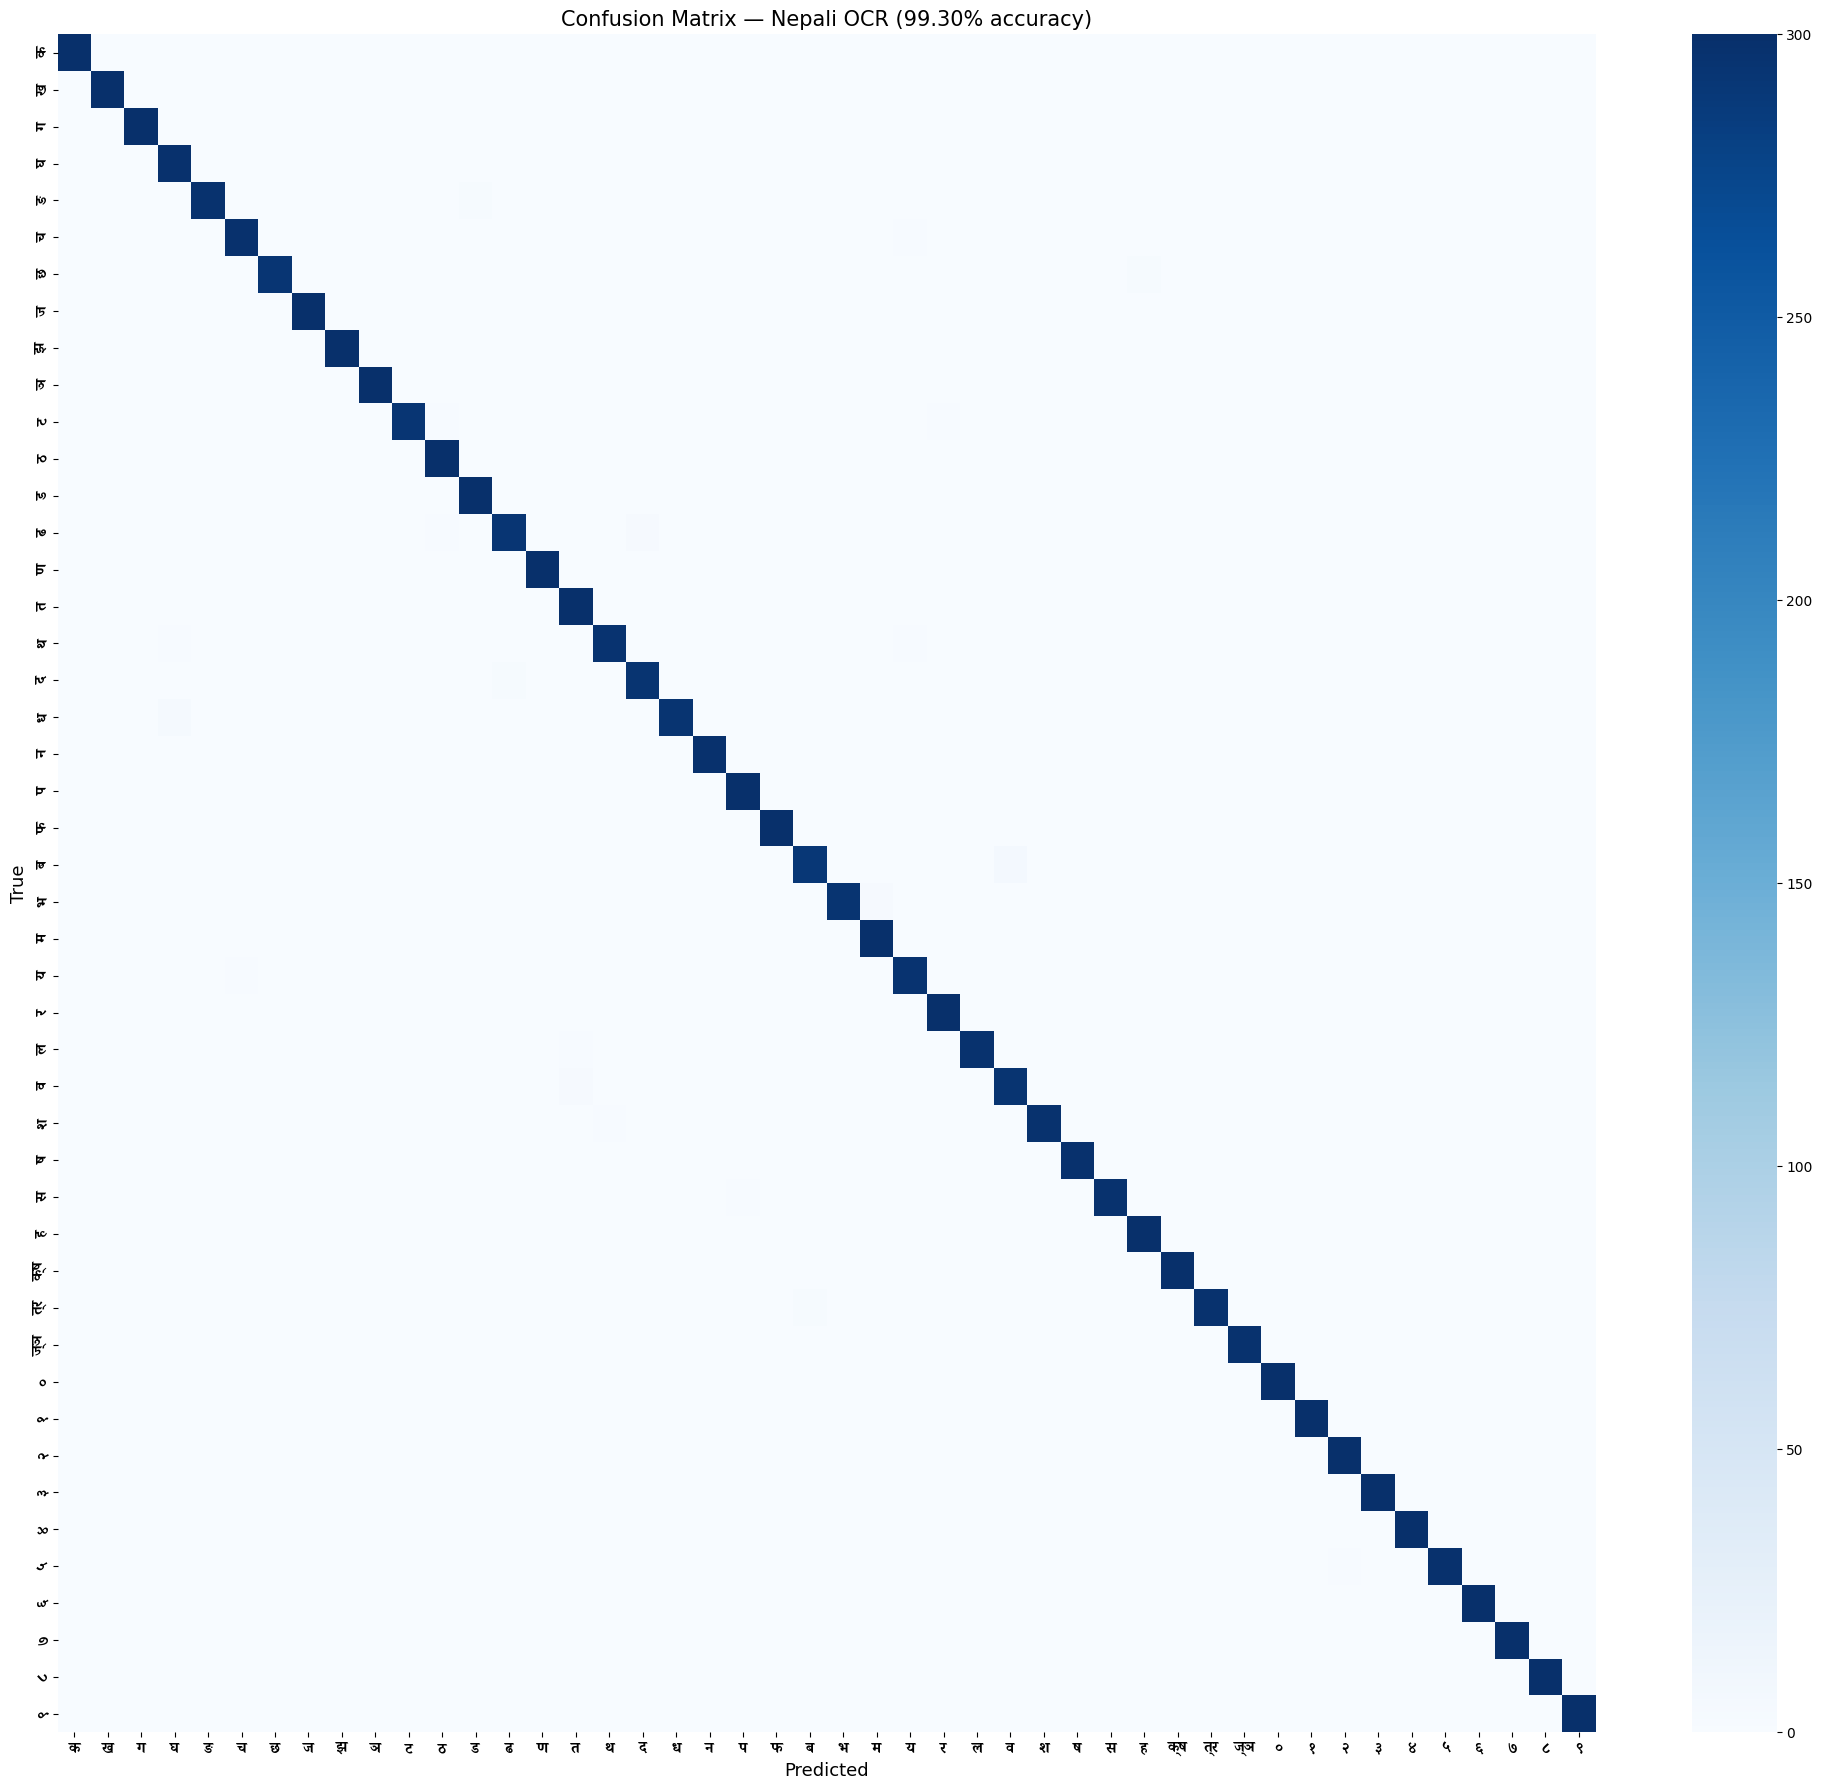


Per-class accuracy:
  क → 299/300 = 99.7%
  ख → 300/300 = 100.0%
  ग → 299/300 = 99.7%
  घ → 298/300 = 99.3%
  ङ → 297/300 = 99.0%
  च → 298/300 = 99.3%
  छ → 293/300 = 97.7%
  ज → 299/300 = 99.7%
  झ → 300/300 = 100.0%
  ञ → 299/300 = 99.7%
  ट → 294/300 = 98.0%
  ठ → 300/300 = 100.0%
  ड → 300/300 = 100.0%
  ढ → 294/300 = 98.0%
  ण → 300/300 = 100.0%
  त → 299/300 = 99.7%
  थ → 296/300 = 98.7%
  द → 295/300 = 98.3%
  ध → 295/300 = 98.3%
  न → 298/300 = 99.3%
  प → 299/300 = 99.7%
  फ → 300/300 = 100.0%
  ब → 291/300 = 97.0%
  भ → 295/300 = 98.3%
  म → 300/300 = 100.0%
  य → 296/300 = 98.7%
  र → 299/300 = 99.7%
  ल → 297/300 = 99.0%
  व → 295/300 = 98.3%
  श → 297/300 = 99.0%
  ष → 298/300 = 99.3%
  स → 297/300 = 99.0%
  ह → 300/300 = 100.0%
  क्ष → 299/300 = 99.7%
  त्र → 297/300 = 99.0%
  ज्ञ → 297/300 = 99.0%
  ० → 300/300 = 100.0%
  १ → 299/300 = 99.7%
  २ → 299/300 = 99.7%
  ३ → 299/300 = 99.7%
  ४ → 300/300 = 100.0%
  ५ → 298/300 = 99.3%
  ६ → 299/300 = 99.7%
  ७ → 300/300 = 1

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── Load saved model ──────────────────────────────────────
class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

device = torch.device('cpu')
model  = NepaliOCR_CNN(num_classes=46)
model.load_state_dict(torch.load('/home/kulraj/nepali_ocr/models/nepali_ocr_cnn.pth',
                                  map_location=device))
model.eval()
print("Model loaded!")

# ── Get all predictions ───────────────────────────────────
data   = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_test = data['arr_2']
y_test = data['arr_3'] - 1

all_preds = []
all_true  = []

with torch.no_grad():
    for i in range(len(X_test)):
        img    = torch.tensor(X_test[i].astype(np.float32) / 255.0)
        img    = (img.unsqueeze(0).unsqueeze(0) - 0.5) / 0.5
        out    = model(img)
        pred   = out.argmax(1).item()
        all_preds.append(pred)
        all_true.append(y_test[i])

print(f"Total predictions: {len(all_preds)}")

# ── Plot confusion matrix ─────────────────────────────────
cm   = confusion_matrix(all_true, all_preds)
prop = fm.FontProperties(
    fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)

ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('Confusion Matrix — Nepali OCR (99.30% accuracy)', fontsize=15)

# Apply Devanagari font to tick labels
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(11)
for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(11)

plt.tight_layout()
plt.show()

# ── Print hardest classes ─────────────────────────────────
print("\nPer-class accuracy:")
for i in range(46):
    class_total   = (np.array(all_true) == i).sum()
    class_correct = cm[i, i]
    print(f"  {CLASS_NAMES[i]} → {class_correct}/{class_total} = {class_correct/class_total*100:.1f}%")

In [1]:
# ── Add अ आ and all independent vowels to CNN ─────────────────
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import random

FONT_PATH = '/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf'

# New classes to add — independent vowels
NEW_CHARS = ['अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ए', 'ऐ', 'ओ', 'औ']

def render_char_augmented(char, n=1700):
    images = []
    font_sizes = [28, 32, 36, 40, 44, 48]
    for _ in range(n):
        size  = random.choice(font_sizes)
        font  = ImageFont.truetype(FONT_PATH, size=size)
        img   = Image.new('L', (64, 64), color=255)
        draw  = ImageDraw.Draw(img)
        bbox  = draw.textbbox((0,0), char, font=font)
        w, h  = bbox[2]-bbox[0], bbox[3]-bbox[1]
        x     = random.randint(2, max(3, 64-w-2))
        y     = random.randint(2, max(3, 64-h-2))
        draw.text((x, y), char, font=font, fill=0)
        # Random rotation
        angle = random.uniform(-10, 10)
        img   = img.rotate(angle, fillcolor=255)
        # Resize to 32x32
        img   = img.resize((32, 32), Image.LANCZOS)
        images.append(np.array(img))
    return np.array(images, dtype=np.uint8)

# Generate images for each new vowel
all_new_images = []
all_new_labels = []

# Current CNN has 46 classes (0-45)
# New vowels start from class 46
for i, char in enumerate(NEW_CHARS):
    imgs   = render_char_augmented(char, n=1700)
    labels = np.full(1700, 46 + i, dtype=np.int64)
    all_new_images.append(imgs)
    all_new_labels.append(labels)
    print(f"Generated {char}: {imgs.shape}")

all_new_images = np.concatenate(all_new_images, axis=0)
all_new_labels = np.concatenate(all_new_labels, axis=0)

print(f"\nNew data shape: {all_new_images.shape}")
print(f"New labels: {all_new_labels.min()} to {all_new_labels.max()}")

# Preview
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
prop = fm.FontProperties(fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')
for i, ax in enumerate(axes.flat):
    ax.imshow(all_new_images[i*170], cmap='gray')
    ax.set_title(NEW_CHARS[i], fontproperties=prop, fontsize=14)
    ax.axis('off')
plt.suptitle('New vowel training samples', fontsize=13)
plt.tight_layout()
plt.show()

Generated अ: (1700, 32, 32)
Generated आ: (1700, 32, 32)
Generated इ: (1700, 32, 32)
Generated ई: (1700, 32, 32)
Generated उ: (1700, 32, 32)
Generated ऊ: (1700, 32, 32)
Generated ए: (1700, 32, 32)
Generated ऐ: (1700, 32, 32)
Generated ओ: (1700, 32, 32)
Generated औ: (1700, 32, 32)

New data shape: (17000, 32, 32)
New labels: 46 to 55


NameError: name 'plt' is not defined

/tmp/ipykernel_7562/455783241.py:12: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7562/455783241.py:12: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


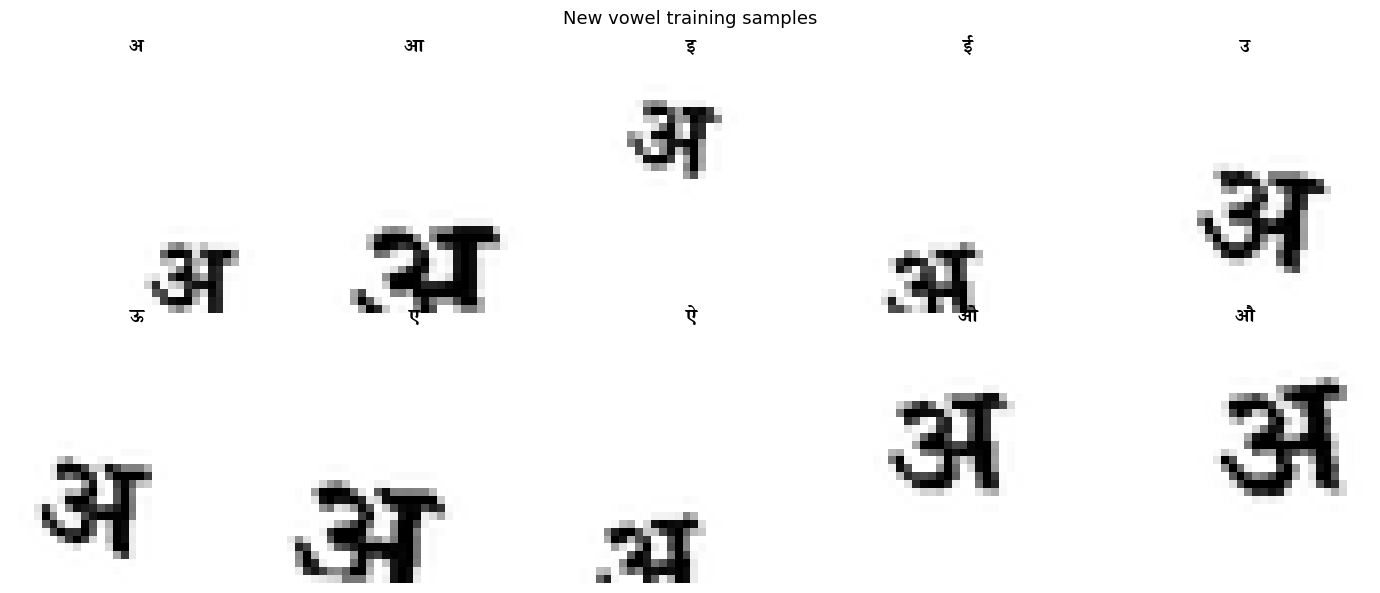

Preview done!


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Preview
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
prop = fm.FontProperties(fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')
for i, ax in enumerate(axes.flat):
    ax.imshow(all_new_images[i*170], cmap='gray')
    ax.set_title(NEW_CHARS[i], fontproperties=prop, fontsize=14)
    ax.axis('off')
plt.suptitle('New vowel training samples', fontsize=13)
plt.tight_layout()
plt.show()
print("Preview done!")

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Extended class names — 46 original + 10 vowels = 56 total
CLASS_NAMES_EXT = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
                   'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
                   'प','फ','ब','भ','म','य','र','ल','व','श',
                   'ष','स','ह','क्ष','त्र','ज्ञ',
                   '०','१','२','३','४','५','६','७','८','९',
                   'अ','आ','इ','ई','उ','ऊ','ए','ऐ','ओ','औ']

print(f"Total classes: {len(CLASS_NAMES_EXT)}")

# Load original DHCD data
dhcd    = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_train = dhcd['arr_0']
y_train = dhcd['arr_1'] - 1
X_test  = dhcd['arr_2']
y_test  = dhcd['arr_3'] - 1

# Split new vowel data 80/20
split        = int(0.8 * len(all_new_images))
X_new_train  = all_new_images[:split]
y_new_train  = all_new_labels[:split]
X_new_test   = all_new_images[split:]
y_new_test   = all_new_labels[split:]

# Combine
X_train_ext = np.concatenate([X_train, X_new_train], axis=0)
y_train_ext = np.concatenate([y_train, y_new_train], axis=0)
X_test_ext  = np.concatenate([X_test,  X_new_test],  axis=0)
y_test_ext  = np.concatenate([y_test,  y_new_test],  axis=0)

print(f"Train: {X_train_ext.shape} | Test: {X_test_ext.shape}")

# Dataset
class DHCDDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images  = images.astype(np.float32) / 255.0
        self.labels  = labels.astype(np.int64)
        self.augment = augment
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).unsqueeze(0)
        if self.augment:
            img = T.RandomRotation(10)(img)
            img = T.RandomAffine(degrees=0, translate=(0.1,0.1))(img)
        img = T.Normalize((0.5,),(0.5,))(img)
        return img, self.labels[idx]

train_ds = DHCDDataset(X_train_ext, y_train_ext, augment=True)
test_ds  = DHCDDataset(X_test_ext,  y_test_ext,  augment=False)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print("Ready to train!")

Total classes: 56
Train: (91800, 32, 32) | Test: (17200, 32, 32)
Train batches: 1435
Ready to train!


In [5]:
# ── Train extended CNN with vowels ────────────────────────────
class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=56):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

device    = torch.device('cpu')
torch.set_num_threads(6)
model_ext = NepaliOCR_CNN(num_classes=56).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ext.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 30
for epoch in range(EPOCHS):
    model_ext.train()
    total_loss = 0; correct = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model_ext(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
    train_acc = correct / len(train_ds) * 100

    model_ext.eval()
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            val_correct += (model_ext(imgs).argmax(1) == labels).sum().item()
    val_acc = val_correct / len(test_ds) * 100
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

print("\nSaving...")
torch.save(model_ext.state_dict(), '/home/kulraj/nepali_ocr/models/nepali_ocr_cnn_v2.pth')
print("Saved to models/nepali_ocr_cnn_v2.pth")

Epoch 01/30 | Loss: 1.7240 | Train: 47.13% | Val: 74.63%
Epoch 02/30 | Loss: 0.8926 | Train: 70.23% | Val: 76.46%
Epoch 03/30 | Loss: 0.6817 | Train: 77.69% | Val: 77.47%
Epoch 04/30 | Loss: 0.5623 | Train: 82.01% | Val: 78.10%
Epoch 05/30 | Loss: 0.4781 | Train: 84.77% | Val: 78.06%
Epoch 06/30 | Loss: 0.4018 | Train: 87.35% | Val: 78.37%
Epoch 07/30 | Loss: 0.3411 | Train: 89.51% | Val: 78.79%
Epoch 08/30 | Loss: 0.3037 | Train: 90.61% | Val: 78.97%
Epoch 09/30 | Loss: 0.2748 | Train: 91.62% | Val: 79.08%
Epoch 10/30 | Loss: 0.2494 | Train: 92.36% | Val: 79.10%
Epoch 11/30 | Loss: 0.2029 | Train: 93.97% | Val: 79.37%
Epoch 12/30 | Loss: 0.1834 | Train: 94.43% | Val: 79.27%
Epoch 13/30 | Loss: 0.1719 | Train: 94.82% | Val: 79.41%
Epoch 14/30 | Loss: 0.1619 | Train: 95.21% | Val: 79.47%
Epoch 15/30 | Loss: 0.1532 | Train: 95.37% | Val: 79.51%
Epoch 16/30 | Loss: 0.1507 | Train: 95.47% | Val: 79.51%
Epoch 17/30 | Loss: 0.1407 | Train: 95.84% | Val: 79.51%
Epoch 18/30 | Loss: 0.1352 | Tr

Extended model predictions:
────────────────────────────────────────
✓ True: अ | Pred: अ (100.0%)
✓ True: आ | Pred: आ (100.0%)
✓ True: इ | Pred: इ (100.0%)
✓ True: ई | Pred: ई (100.0%)
✓ True: उ | Pred: उ (100.0%)
✗ True: क | Pred: ऊ (100.0%)
✗ True: ख | Pred: ऊ (95.8%)
✗ True: न | Pred: उ (100.0%)
✗ True: प | Pred: ए (100.0%)
✗ True: म | Pred: ए (99.9%)


/tmp/ipykernel_7562/3581727186.py:32: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7562/3581727186.py:32: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7562/3581727186.py:32: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Noto Serif Devanagari.
  f

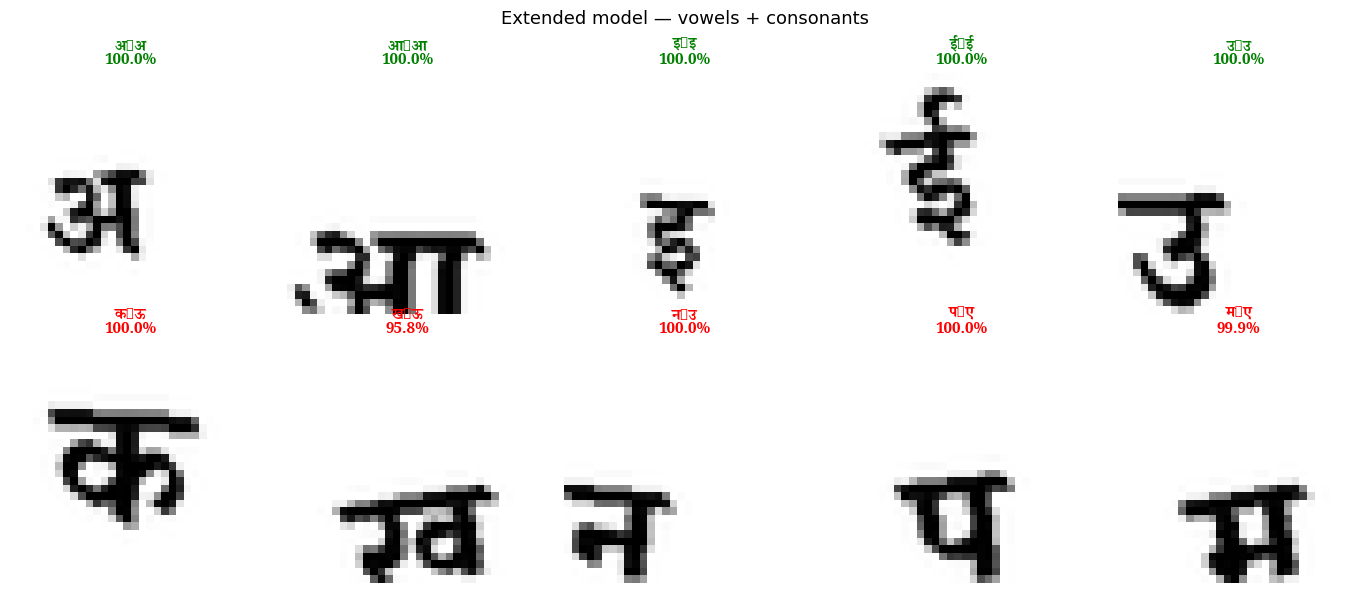

In [6]:
# ── Test new model on vowels ──────────────────────────────────
model_ext.eval()

test_chars = ['अ', 'आ', 'इ', 'ई', 'उ', 'क', 'ख', 'न', 'प', 'म']

print("Extended model predictions:")
print("─" * 40)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, char in enumerate(test_chars):
    # Generate test image
    img = render_char_augmented(char, n=1)[0]
    tensor = torch.tensor(img.astype(np.float32)/255.0).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    
    with torch.no_grad():
        out  = model_ext(tensor)
        pred = out.argmax(1).item()
        conf = out.softmax(1)[0][pred].item()
    
    predicted_char = CLASS_NAMES_EXT[pred]
    correct = predicted_char == char
    print(f"{'✓' if correct else '✗'} True: {char} | Pred: {predicted_char} ({conf*100:.1f}%)")
    
    color = 'green' if correct else 'red'
    axes[i//5][i%5].imshow(img, cmap='gray')
    axes[i//5][i%5].set_title(f"{char}→{predicted_char}\n{conf*100:.1f}%",
                               fontproperties=prop, fontsize=11, color=color)
    axes[i//5][i%5].axis('off')

plt.suptitle('Extended model — vowels + consonants', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ── Test with real DHCD images ────────────────────────────────
dhcd   = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_test = dhcd['arr_2']
y_test = dhcd['arr_3'] - 1

model_ext.eval()
correct_count = 0
total         = 500

# Test 500 random DHCD samples
indices = np.random.choice(len(X_test), total, replace=False)

for idx in indices:
    img    = X_test[idx]
    label  = y_test[idx]
    tensor = torch.tensor(img.astype(np.float32)/255.0).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    with torch.no_grad():
        out  = model_ext(tensor)
        pred = out.argmax(1).item()
    if pred == label:
        correct_count += 1

print(f"Accuracy on real DHCD handwritten images: {correct_count}/{total} = {correct_count/total*100:.1f}%")

Accuracy on real DHCD handwritten images: 498/500 = 99.6%


Generated ॐ: (1700, 32, 32)
Generated अं: (1700, 32, 32)
Generated अः: (1700, 32, 32)

Special data shape: (5100, 32, 32)


/tmp/ipykernel_7562/3440737805.py:28: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7562/3440737805.py:28: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()


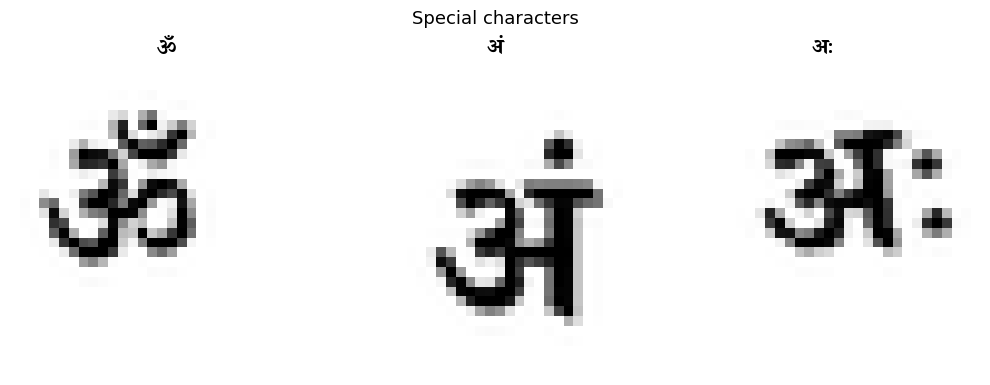

In [8]:
# ── Add ॐ अं अः to CNN ────────────────────────────────────────
NEW_SPECIAL = ['ॐ', 'अं', 'अः']

all_special_images = []
all_special_labels = []

# Current model has 56 classes (0-55)
# New special chars start from 56
for i, char in enumerate(NEW_SPECIAL):
    imgs   = render_char_augmented(char, n=1700)
    labels = np.full(1700, 56 + i, dtype=np.int64)
    all_special_images.append(imgs)
    all_special_labels.append(labels)
    print(f"Generated {char}: {imgs.shape}")

all_special_images = np.concatenate(all_special_images, axis=0)
all_special_labels = np.concatenate(all_special_labels, axis=0)

print(f"\nSpecial data shape: {all_special_images.shape}")

# Preview
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(all_special_images[i*1700], cmap='gray')
    ax.set_title(NEW_SPECIAL[i], fontproperties=prop, fontsize=16)
    ax.axis('off')
plt.suptitle('Special characters', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# ── Combine all data and retrain with 59 classes ──────────────
CLASS_NAMES_V3 = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
                  'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
                  'प','फ','ब','भ','म','य','र','ल','व','श',
                  'ष','स','ह','क्ष','त्र','ज्ञ',
                  '०','१','२','३','४','५','६','७','८','९',
                  'अ','आ','इ','ई','उ','ऊ','ए','ऐ','ओ','औ',
                  'ॐ','अं','अः']

print(f"Total classes: {len(CLASS_NAMES_V3)}")

# Load previous combined data
dhcd    = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_dhcd  = dhcd['arr_0']
y_dhcd  = dhcd['arr_1'] - 1

# Split new+special 80/20
all_extra        = np.concatenate([all_new_images, all_special_images], axis=0)
all_extra_labels = np.concatenate([all_new_labels, all_special_labels], axis=0)

split        = int(0.8 * len(all_extra))
X_extra_train = all_extra[:split]
y_extra_train = all_extra_labels[:split]
X_extra_test  = all_extra[split:]
y_extra_test  = all_extra_labels[split:]

# Combine with DHCD
X_train_v3 = np.concatenate([X_dhcd, X_extra_train], axis=0)
y_train_v3 = np.concatenate([y_dhcd, y_extra_train], axis=0)

print(f"Train: {X_train_v3.shape}")
print(f"Classes: {y_train_v3.min()} to {y_train_v3.max()}")

# Dataset and loaders
train_ds_v3 = DHCDDataset(X_train_v3, y_train_v3, augment=True)
train_loader_v3 = DataLoader(train_ds_v3, batch_size=64, shuffle=True, num_workers=0)

# Train
model_v3  = NepaliOCR_CNN(num_classes=59).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v3.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 30
for epoch in range(EPOCHS):
    model_v3.train()
    total_loss = 0; correct = 0
    for imgs, labels in train_loader_v3:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model_v3(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
    train_acc = correct / len(train_ds_v3) * 100
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader_v3):.4f} | Train: {train_acc:.2f}%")

print("\nSaving...")
torch.save(model_v3.state_dict(), '/home/kulraj/nepali_ocr/models/nepali_ocr_cnn_v3.pth')
print("Saved to models/nepali_ocr_cnn_v3.pth")

Total classes: 59
Train: (95880, 32, 32)
Classes: 0 to 56
Epoch 01/30 | Loss: 1.7241 | Train: 47.07%
Epoch 02/30 | Loss: 0.8600 | Train: 71.47%
Epoch 03/30 | Loss: 0.6518 | Train: 78.35%
Epoch 04/30 | Loss: 0.5322 | Train: 82.81%
Epoch 05/30 | Loss: 0.4539 | Train: 85.52%
Epoch 06/30 | Loss: 0.3960 | Train: 87.43%
Epoch 07/30 | Loss: 0.3432 | Train: 89.22%
Epoch 08/30 | Loss: 0.3049 | Train: 90.60%
Epoch 09/30 | Loss: 0.2692 | Train: 91.74%
Epoch 10/30 | Loss: 0.2431 | Train: 92.61%
Epoch 11/30 | Loss: 0.1944 | Train: 94.13%
Epoch 12/30 | Loss: 0.1782 | Train: 94.58%
Epoch 13/30 | Loss: 0.1671 | Train: 94.96%
Epoch 14/30 | Loss: 0.1608 | Train: 95.13%
Epoch 15/30 | Loss: 0.1512 | Train: 95.41%
Epoch 16/30 | Loss: 0.1468 | Train: 95.67%
Epoch 17/30 | Loss: 0.1415 | Train: 95.70%
Epoch 18/30 | Loss: 0.1352 | Train: 95.98%
Epoch 19/30 | Loss: 0.1311 | Train: 96.02%
Epoch 20/30 | Loss: 0.1276 | Train: 96.13%
Epoch 21/30 | Loss: 0.1135 | Train: 96.56%
Epoch 22/30 | Loss: 0.1052 | Train: 96.